# Section 5.5: Test 4 - Category Recognition

This section notebook uses the authoritative Test 4 results generated by `test4_category-recognition.ipynb` rather than re-running a parallel scoring workflow.

**Primary data source:** `results/data/test4_results.csv`
**Raw response reference:** `ai_responses/all_responses.json`

## Goal

Provide reproducible integrity checks and publication-ready summary outputs for Section 5.5 while maintaining a single scoring implementation.

In [8]:
import json
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [9]:

_cwd = Path.cwd().resolve()
_root_candidates = [_cwd, *_cwd.parents]
RESEARCH_ROOT = next(
    candidate for candidate in _root_candidates
    if (candidate / 'setups').exists() and (candidate / 'test4_category-recognition').exists()
)
NOTEBOOK_DIR = RESEARCH_ROOT / 'test4_category-recognition'
if str(RESEARCH_ROOT) not in sys.path:
    sys.path.insert(0, str(RESEARCH_ROOT))
os.chdir(RESEARCH_ROOT)

results_dir = NOTEBOOK_DIR / 'results'
section_data_dir = results_dir / 'data'
section_figures_dir = results_dir / 'figures'
section_data_dir.mkdir(parents=True, exist_ok=True)
section_figures_dir.mkdir(parents=True, exist_ok=True)

canonical_dir = section_figures_dir
section_output_dir = section_figures_dir
canonical_results_file = section_data_dir / 'test4_results.csv'
raw_responses_file = NOTEBOOK_DIR / 'ai_responses/all_responses.json'

print('Section 5.5 initialized (imported-results mode).')
print(f'Test 4 figures directory: {section_figures_dir}')
print(f'Test 4 data directory: {section_data_dir}')
print(f'Test 4 results file: {canonical_results_file}')

Section 5.5 initialized (imported-results mode).
Test 4 figures directory: /home/jarnoma/Yandex.Disk/OneDrive - UrFU/UrFU-DOCTOR/Dissertation/Articles/AI-Creativity/Code Project/research/test4_category-recognition/results/figures
Test 4 data directory: /home/jarnoma/Yandex.Disk/OneDrive - UrFU/UrFU-DOCTOR/Dissertation/Articles/AI-Creativity/Code Project/research/test4_category-recognition/results/data
Test 4 results file: /home/jarnoma/Yandex.Disk/OneDrive - UrFU/UrFU-DOCTOR/Dissertation/Articles/AI-Creativity/Code Project/research/test4_category-recognition/results/data/test4_results.csv


In [10]:
from setups.viz_styles import WHITE_SKY_CMAP, TEXT_COLOR

plt.style.use(str(RESEARCH_ROOT / 'setups/plotstyles.mplstyle'))

figure_names_for_sync = [
    'category_awareness_scores_by_model.png',
    'score_distributions.png',
    'embedding_space_analysis.png',
]

In [11]:
if not canonical_results_file.exists():
    raise FileNotFoundError(
        f'Test 4 results file not found: {canonical_results_file}. '
        'Run test4_category-recognition.ipynb to generate it.'
    )

results_df = pd.read_csv(canonical_results_file)

required_columns = [
    'Sample_ID', 'Model', 'Scenario_Type', 'Parsed_OK',
    'Categories_Identified', 'Contested_Categories',
    'Category_Mistakes', 'Missed_Distinctions',
    'Distinction_Score', 'Identification_Score',
    'Alternative_Score', 'Total_Score',
    'Training_Derived', 'Similarity',
]
missing_columns = [c for c in required_columns if c not in results_df.columns]
if missing_columns:
    raise ValueError(f'Results file is missing required columns: {missing_columns}')

print(f'Loaded rows: {len(results_df)}')
print(f"Unique models: {results_df['Model'].nunique()}")
print('Scenario distribution:')
print(results_df['Scenario_Type'].value_counts(dropna=False).to_string())

display(results_df.head())

Loaded rows: 168
Unique models: 7
Scenario distribution:
Scenario_Type
standard    168


,Sample_ID,Model,Scenario_Type,Parsed_OK,Categories_Identified,Contested_Categories,Category_Mistakes,Missed_Distinctions,Distinction_Score,Identification_Score,Alternative_Score,Total_Score,Training_Derived,Similarity
0,4,deepseek-v3.2,standard,True,8,3,3,4,3,3,5,11,True,0.456459
1,12,mistral-large,standard,True,8,4,3,4,4,2,5,11,True,0.455141
2,14,deepseek-v3.2,standard,True,9,4,3,4,5,2,5,12,True,0.451348
3,4,llama-3.3-70b-instruct,standard,True,4,3,2,2,0,1,4,5,True,0.474563
4,20,deepseek-v3.2,standard,True,7,4,3,4,4,3,5,12,True,0.484309


## 1. Data Integrity Checks

In [12]:
if not raw_responses_file.exists():
    raise FileNotFoundError(f'Raw responses file not found: {raw_responses_file}')

with open(raw_responses_file, 'r', encoding='utf-8') as f:
    raw_responses = json.load(f)

raw_count = len(raw_responses)
results_count = len(results_df)
parsed_ok_count = int(results_df['Parsed_OK'].fillna(False).sum())
parsed_ok_rate = parsed_ok_count / results_count if results_count else np.nan

integrity_summary = {
    'raw_response_rows': raw_count,
    'results_rows': results_count,
    'row_count_match': raw_count == results_count,
    'parsed_ok_count': parsed_ok_count,
    'parsed_ok_rate': float(parsed_ok_rate),
    'models': sorted(results_df['Model'].dropna().unique().tolist()),
    'scenario_types': sorted(results_df['Scenario_Type'].dropna().unique().tolist()),
}

print('INTEGRITY SUMMARY')
print('=' * 60)
for key, value in integrity_summary.items():
    print(f'{key}: {value}')

if raw_count != results_count:
    print('\nWARNING: Row counts differ between raw responses and scored results.')
else:
    print('\nRow counts are aligned between raw responses and scored results.')

INTEGRITY SUMMARY
raw_response_rows: 168
results_rows: 168
row_count_match: True
parsed_ok_count: 165
parsed_ok_rate: 0.9821428571428571
models: ['claude-3.7-sonnet', 'deepseek-v3.2', 'gemini-3.1-pro-preview', 'gpt-5.2', 'llama-3.3-70b-instruct', 'mistral-large', 'perplexity-sonar-pro']
scenario_types: ['standard']

Row counts are aligned between raw responses and scored results.


## 2. Descriptive Statistics (Imported Test 4 Scores)

In [13]:
score_columns = ['Distinction_Score', 'Identification_Score', 'Alternative_Score', 'Total_Score']

overall_summary = results_df[score_columns].agg(['mean', 'std', 'min', 'max']).round(3)
model_summary = (
    results_df.groupby('Model', as_index=False)[score_columns]
    .mean()
    .sort_values('Total_Score', ascending=False)
    .reset_index(drop=True)
)

scenario_summary = (
    results_df.groupby('Scenario_Type', dropna=False)[score_columns]
    .mean()
    .round(3)
)

print('OVERALL SCORE SUMMARY')
display(overall_summary)

print('MODEL-LEVEL MEAN SCORES')
display(model_summary)

print('SCENARIO-LEVEL MEAN SCORES')
display(scenario_summary)

OVERALL SCORE SUMMARY


,Distinction_Score,Identification_Score,Alternative_Score,Total_Score
mean,2.577,2.786,3.310,8.673
std,1.647,0.936,1.233,2.956
min,0.000,0.000,0.000,0.000
max,5.000,5.000,5.000,14.000


MODEL-LEVEL MEAN SCORES


,Model,Distinction_Score,Identification_Score,Alternative_Score,Total_Score
0,gpt-5.2,5.000000,4.083333,3.291667,12.375000
1,deepseek-v3.2,3.583333,3.041667,3.791667,10.416667
2,mistral-large,3.458333,2.625000,3.791667,9.875000
3,claude-3.7-sonnet,2.333333,2.750000,3.833333,8.916667
4,gemini-3.1-pro-preview,1.500000,2.666667,2.791667,6.958333
5,perplexity-sonar-pro,1.791667,2.750000,1.875000,6.416667
6,llama-3.3-70b-instruct,0.375000,1.583333,3.791667,5.750000


SCENARIO-LEVEL MEAN SCORES


,Distinction_Score,Identification_Score,Alternative_Score,Total_Score
Scenario_Type,,,,
standard,2.577,2.786,3.31,8.673


## 3. Visual Analysis (Imported Test 4 Outputs)

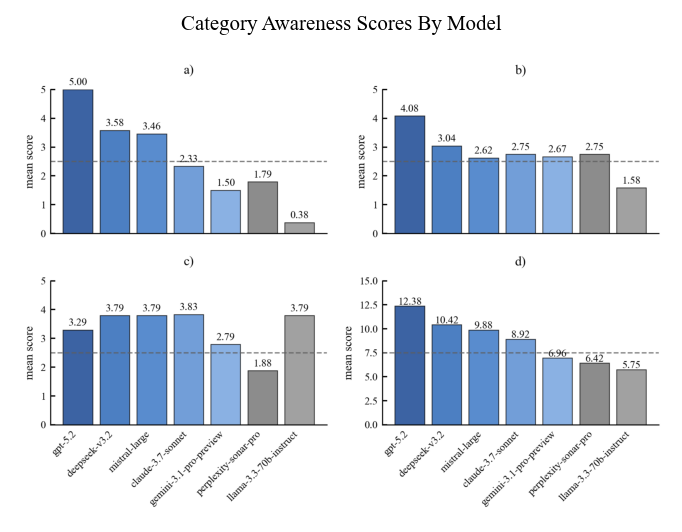

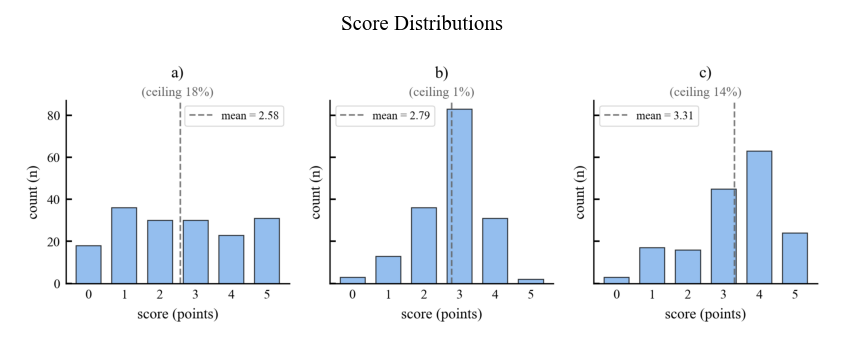

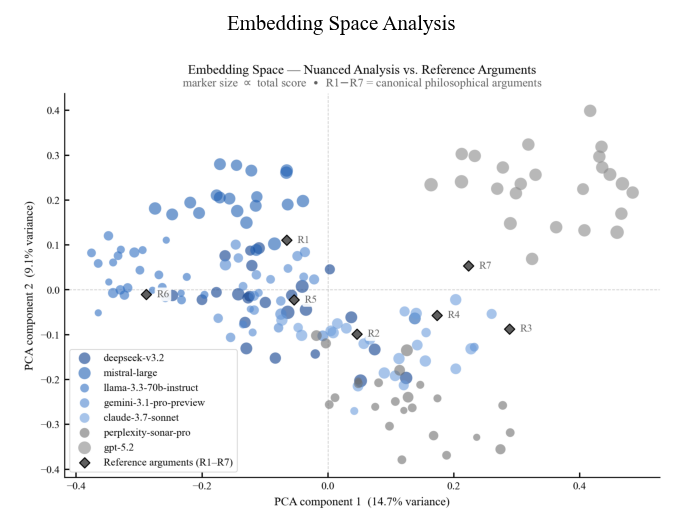

In [14]:
canonical_figures = [
    'category_awareness_scores_by_model.png',
    'score_distributions.png',
    'embedding_space_analysis.png',
]

for figure_name in canonical_figures:
    figure_path = section_figures_dir / figure_name
    if figure_path.exists():
        image = plt.imread(figure_path)
        plt.figure(figsize=(7, 4))
        plt.imshow(image)
        plt.axis('off')
        plt.title(figure_name.replace('_', ' ').replace('.png', '').title())
        plt.show()
    else:
        print(f'Missing Test 4 figure: {figure_path}')

# Section-specific plot based on the imported Test 4 CSV output.
plot_df = model_summary.copy()
plot_df = plot_df.sort_values('Total_Score', ascending=False).reset_index(drop=True)

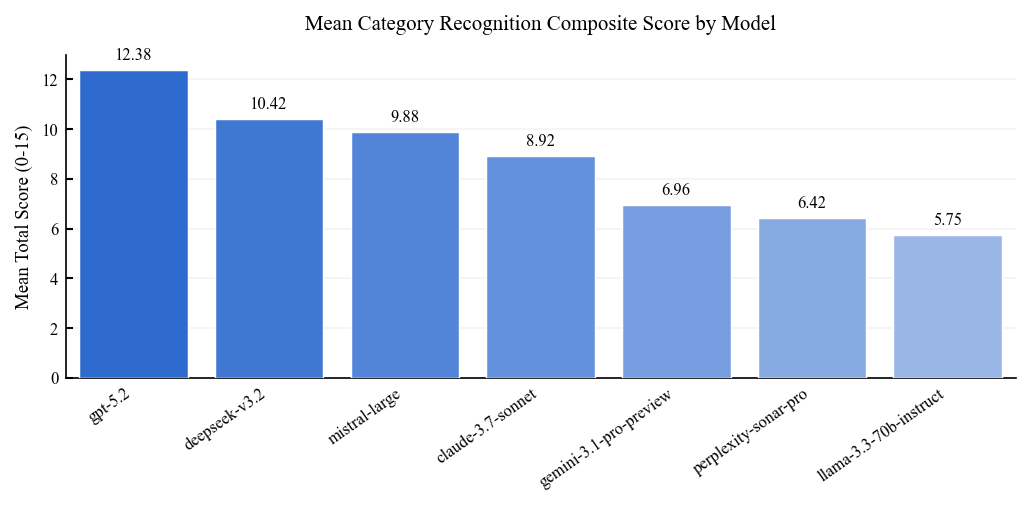

Section plot saved to: /home/jarnoma/Yandex.Disk/OneDrive - UrFU/UrFU-DOCTOR/Dissertation/Articles/AI-Creativity/Code Project/research/test4_category-recognition/results/figures/total_score_by_model.png
Section summary saved to: /home/jarnoma/Yandex.Disk/OneDrive - UrFU/UrFU-DOCTOR/Dissertation/Articles/AI-Creativity/Code Project/research/test4_category-recognition/results/data/summary_from_main_pipeline.json


In [16]:
# Higher mean score -> darker blue; lower mean score -> lighter blue.
model_palette = [WHITE_SKY_CMAP(v) for v in np.linspace(0.92, 0.45, len(plot_df))]

plt.figure(figsize=(7, 3.5))
ax = sns.barplot(
    data=plot_df,
    x='Model',
    y='Total_Score',
    hue='Model',
    palette=model_palette,
    dodge=False,
    legend=False,
    edgecolor='white',
    linewidth=0.7,
    zorder=3,
    ax=plt.gca(),
)
plt.title('Mean Category Recognition Composite Score by Model')
plt.ylabel('Mean Total Score (0-15)')
plt.xlabel('')
plt.xticks(rotation=35, ha='right')
plt.tick_params(axis='x', which='both', bottom=False)  # Hide x-axis ticks

# Place y-grid behind bars for clean layering.
ax.set_axisbelow(True)
ax.grid(axis='y', alpha=0.25, zorder=0)

# Add value labels above each bar.
for patch in ax.patches:
    height = patch.get_height()
    if np.isfinite(height):
        ax.annotate(
            f'{height:.2f}',
            (patch.get_x() + patch.get_width() / 2, height),
            ha='center',
            va='bottom',
            xytext=(0, 3),
            textcoords='offset points',
            fontsize=8,
            color=TEXT_COLOR,
        )

plt.tight_layout()

section_plot_path = section_output_dir / 'total_score_by_model.png'
plt.savefig(section_plot_path, bbox_inches='tight')
plt.show()

section_summary_path = section_data_dir / 'summary_from_main_pipeline.json'
section_summary = {
    'source_results_csv': str(canonical_results_file),
    'n_rows': int(len(results_df)),
    'n_models': int(results_df['Model'].nunique()),
    'scenario_types': sorted(results_df['Scenario_Type'].dropna().unique().tolist()),
    'mean_scores': {k: float(results_df[k].mean()) for k in score_columns},
}
with open(section_summary_path, 'w', encoding='utf-8') as f:
    json.dump(section_summary, f, indent=2)

print(f'Section plot saved to: {section_plot_path}')
print(f'Section summary saved to: {section_summary_path}')